In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

In [2]:
import os
import sys

# Add the scripts/pypsa-de directory to the path
scripts_path = os.path.join(os.path.dirname(os.getcwd()), "scripts", "pypsa-de")
sys.path.append(scripts_path)

from flexibility_utils import tech_colors

# ffe data

In [3]:
url = "https://api.opendata.ffe.de"
params = {
    "id_opendata": 59,
    # "internat_id_type": 126,
    # "internal_id_1": 0
}

# check if the API is available by making a GET request to the /health endpoint
response = requests.get(url + "/health")
if not response.status_code == 200:
    print(f"API not available. Status code: {response.status_code}")
    print(response.json())
    exit()

print("API available.")

# fetch the data by making a GET request to the 'opendata' endpoint
# using the previously defined parameters
response = requests.get(url + "/opendata", params=params)

# check if the request was successful
if not response.status_code == 200:
    print(f"Request failed. Status code: {response.status_code}.")
    print(response.json())
    exit()

print("Request successful.")

# get the response as a dictionary
data = response.json()

# print some of the metadata
print(f"id_opendata: {data['id_opendata']}")
print(f"title: {data['title']}")

API available.
Request successful.
id_opendata: 59
title: Normed Industrial Electrical Load Profile (Germany)


In [4]:
df_api = pd.DataFrame(data["data"])
df_api

,id_opendata,id_region_type,id_region,year,year_weather,internal_id,values
0,59,35,276,2017,2017,[5],"[5.68064e-05, 5.60751e-05, 5.5804e-05, 5.55121..."
1,59,35,276,2017,2017,[7],"[2.31191e-05, 2.292e-05, 2.21905e-05, 2.20858e..."
2,59,35,276,2017,2017,[8],"[6.45564e-05, 6.61523e-05, 6.48901e-05, 6.4461..."
3,59,35,276,2017,2017,[6],"[5.68064e-05, 5.60751e-05, 5.5804e-05, 5.55121..."
4,59,35,276,2017,2017,[10],"[5.47855e-05, 5.35655e-05, 5.30792e-05, 5.3563..."
5,59,35,276,2017,2017,[11],"[5.47855e-05, 5.35655e-05, 5.30792e-05, 5.3563..."
6,59,35,276,2017,2017,[12],"[5.47855e-05, 5.35655e-05, 5.30792e-05, 5.3563..."
7,59,35,276,2017,2017,[1],"[0.0001126111, 0.0001126111, 0.0001141861, 0.0..."
8,59,35,276,2017,2017,[4],"[8.18078e-05, 8.16067e-05, 7.96701e-05, 7.8265..."
9,59,35,276,2017,2017,[13],"[5.47855e-05, 5.35655e-05, 5.30792e-05, 5.3563..."


- data seems to be incomplete as several ids are missing: 0,2,3

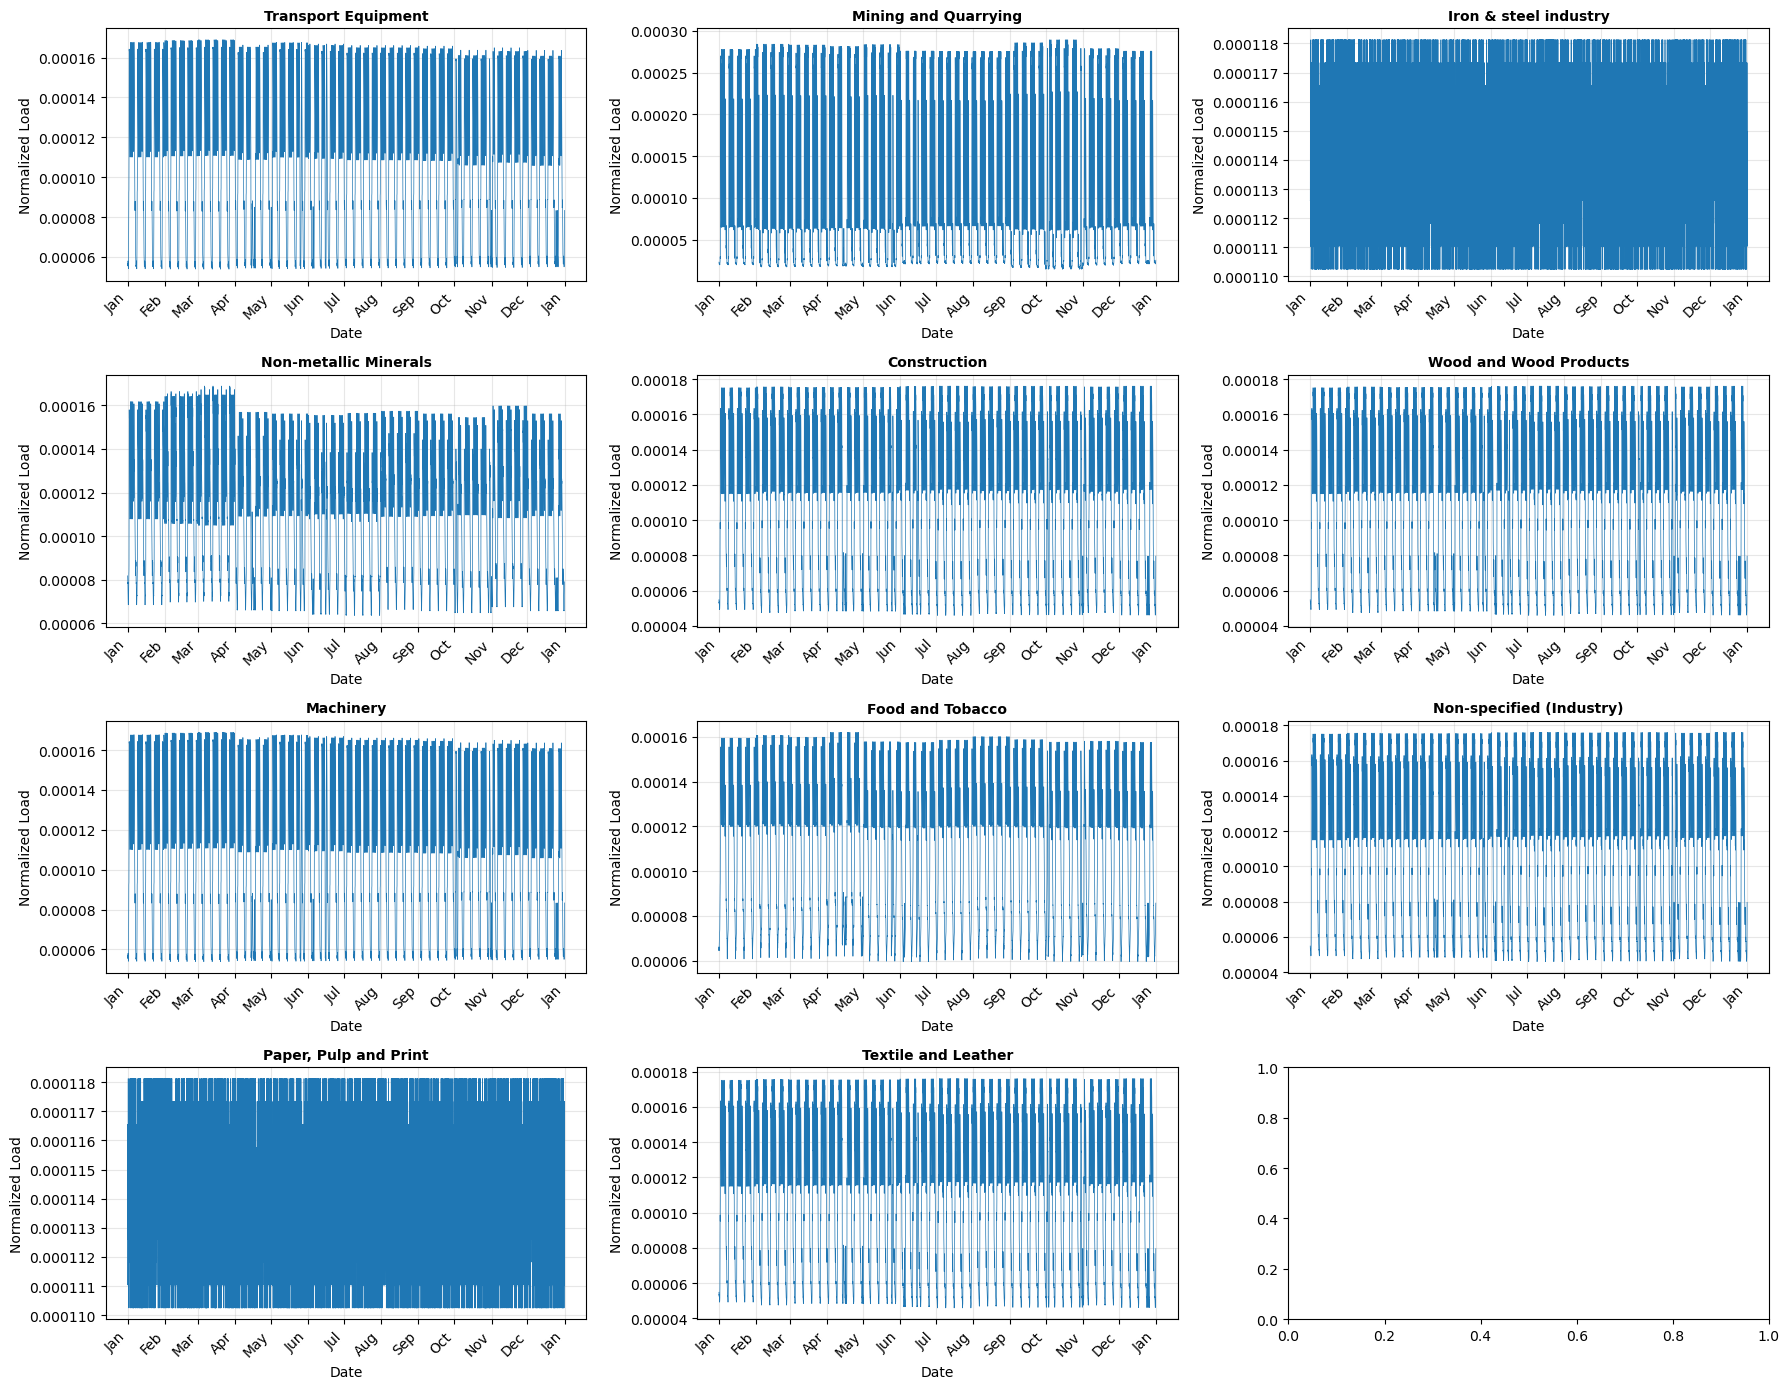


Number of industries: 11
Hours per profile: 8760

Summary statistics:
Transport Equipment            - Min: 0.000054, Max: 0.000169, Mean: 0.000114, Sum: 1.00
Mining and Quarrying           - Min: 0.000015, Max: 0.000289, Mean: 0.000114, Sum: 1.00
Iron & steel industry          - Min: 0.000110, Max: 0.000118, Mean: 0.000114, Sum: 1.00
Non-metallic Minerals          - Min: 0.000064, Max: 0.000169, Mean: 0.000114, Sum: 1.00
Construction                   - Min: 0.000046, Max: 0.000176, Mean: 0.000114, Sum: 1.00
Wood and Wood Products         - Min: 0.000046, Max: 0.000176, Mean: 0.000114, Sum: 1.00
Machinery                      - Min: 0.000054, Max: 0.000169, Mean: 0.000114, Sum: 1.00
Food and Tobacco               - Min: 0.000060, Max: 0.000162, Mean: 0.000114, Sum: 1.00
Non-specified (Industry)       - Min: 0.000046, Max: 0.000176, Mean: 0.000114, Sum: 1.00
Paper, Pulp and Print          - Min: 0.000110, Max: 0.000118, Mean: 0.000114, Sum: 1.00
Textile and Leather            - Min: 0

In [5]:
# also static download seems incomplete

# Load data
filepath = "/home/julian-geis/Documents/06_PhD/02Flexibility/data/industry_load/ffe/id_opendata_59_year_2017.json"

with open(filepath) as f:
    data_list = json.load(f)

# Industry mapping
industry_mapping = {
    0: "Industry (total)",
    1: "Iron & steel industry",
    4: "Non-metallic Minerals",
    5: "Transport Equipment",
    6: "Machinery",
    7: "Mining and Quarrying",
    8: "Food and Tobacco",
    9: "Paper, Pulp and Print",
    10: "Wood and Wood Products",
    11: "Construction",
    12: "Textile and Leather",
    13: "Non-specified (Industry)",
}

# Convert to DataFrame
df = pd.DataFrame(data_list)
df["industry_branch"] = df["internal_id_1"].map(industry_mapping)

# Create datetime index for 2017 (8760 hours)
date_range = pd.date_range("2017-01-01", periods=8760, freq="h")

# Plot all industries
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, (_, row) in enumerate(df.iterrows()):
    ax = axes[idx]
    values = row["values"]

    ax.plot(date_range, values, linewidth=0.5)
    ax.set_title(row["industry_branch"], fontsize=10, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalized Load")
    ax.grid(True, alpha=0.3)

    # Format x-axis to show months
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))

    # Rotate labels
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
# plt.savefig('industry_load_profiles_2017.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nNumber of industries: {len(df)}")
print(f"Hours per profile: {len(df.iloc[0]['values'])}")
print("\nSummary statistics:")
for _, row in df.iterrows():
    values = row["values"]
    print(
        f"{row['industry_branch']:30s} - Min: {min(values):.6f}, Max: {max(values):.6f}, Mean: {sum(values) / len(values):.6f}, Sum: {sum(values):.2f}"
    )

In [22]:
data_list

[{'id_opendata': 59,
  'id_region_type': 35,
  'id_region': 276,
  'year': 2017,
  'year_weather': 2017,
  'internal_id_type': [126],
  'internal_id': [5],
  'internal_id_1': 5,
  'values': [5.68064e-05,
   5.60751e-05,
   5.5804e-05,
   5.55121e-05,
   5.5997e-05,
   5.71617e-05,
   5.79691e-05,
   5.80183e-05,
   5.77727e-05,
   5.76676e-05,
   5.74601e-05,
   5.65992e-05,
   5.53532e-05,
   5.45929e-05,
   5.42905e-05,
   5.40619e-05,
   5.41374e-05,
   5.50198e-05,
   5.72777e-05,
   6.06662e-05,
   6.66163e-05,
   7.67561e-05,
   8.31946e-05,
   8.58115e-05,
   9.25047e-05,
   9.29037e-05,
   9.36299e-05,
   9.98016e-05,
   0.0001093844,
   0.0001299392,
   0.0001548845,
   0.0001642573,
   0.0001635493,
   0.0001638254,
   0.0001630352,
   0.0001640704,
   0.0001613713,
   0.0001571482,
   0.0001542676,
   0.000152014,
   0.0001474578,
   0.0001405323,
   0.0001375754,
   0.0001375171,
   0.0001331306,
   0.0001266097,
   0.0001217004,
   0.0001198085,
   0.000113086,
   0.000110

Based on the paper, the normalization is described in the methodology section. Here's what they do:

## Normalization Process

**Step 1: Initial Normalization (Aufbereitung/Preparation)**
The real load profiles are normalized so that all existing load profiles are **equally weighted** in the regression analysis, regardless of their absolute magnitude. This is mentioned in German as: *"Zuletzt werden die Lastgänge normiert, damit alle existierenden Lastgänge in gleichem Maße in der Regression berücksichtigt werden."*

**Step 3: Re-normalization (Synthetisierung/Synthesis)**
After the synthetic load profile is created through the regression and synthesis process, it undergoes **re-normalization** (*"Synthetisierung & Renormierung"*).

## What "Normalized" Means

The values are **dimensionless** - they represent the relative load pattern normalized to integrate to 1 over the year. This means:

- The sum of all 8760 hourly values for each industry branch equals 1.0
- Each value represents the **fraction of total annual load** occurring in that specific hour
- To get actual energy consumption, you would multiply these normalized values by the total annual energy consumption for that industry branch

This is evident from:
1. The y-axis labels showing "auf 1 normierter Lastgang" (load profile normalized to 1)
2. The values in your data (ranging from ~0.00005 to ~0.00027), which are very small fractions
3. The paper's description that these are used to distribute annual energy consumption temporally

So if you want absolute energy values, you'd need to multiply by the total annual electricity consumption for each industry sector in Germany for 2017.

- source: Wie können europäische Branchen-Lastgänge die Energiewende im Industriesektor unterstützen? (Beitrag in et - Energiewirtschaftliche Tagesfragen, Ausgabe 1/2
Kirstin Ganz, Andrej Guminski, Michael Kolb und Serafin von Roon (Forschungsgesellschaft für Energiewirtschaft mbH))

In [6]:
# How much does the data vary in %


Stats for Transport Equipment:
  Average normalized value: 0.00011416
  January - Min: 47.4%, Max: 146.9%
  May - Min: 47.4%, Max: 146.8%


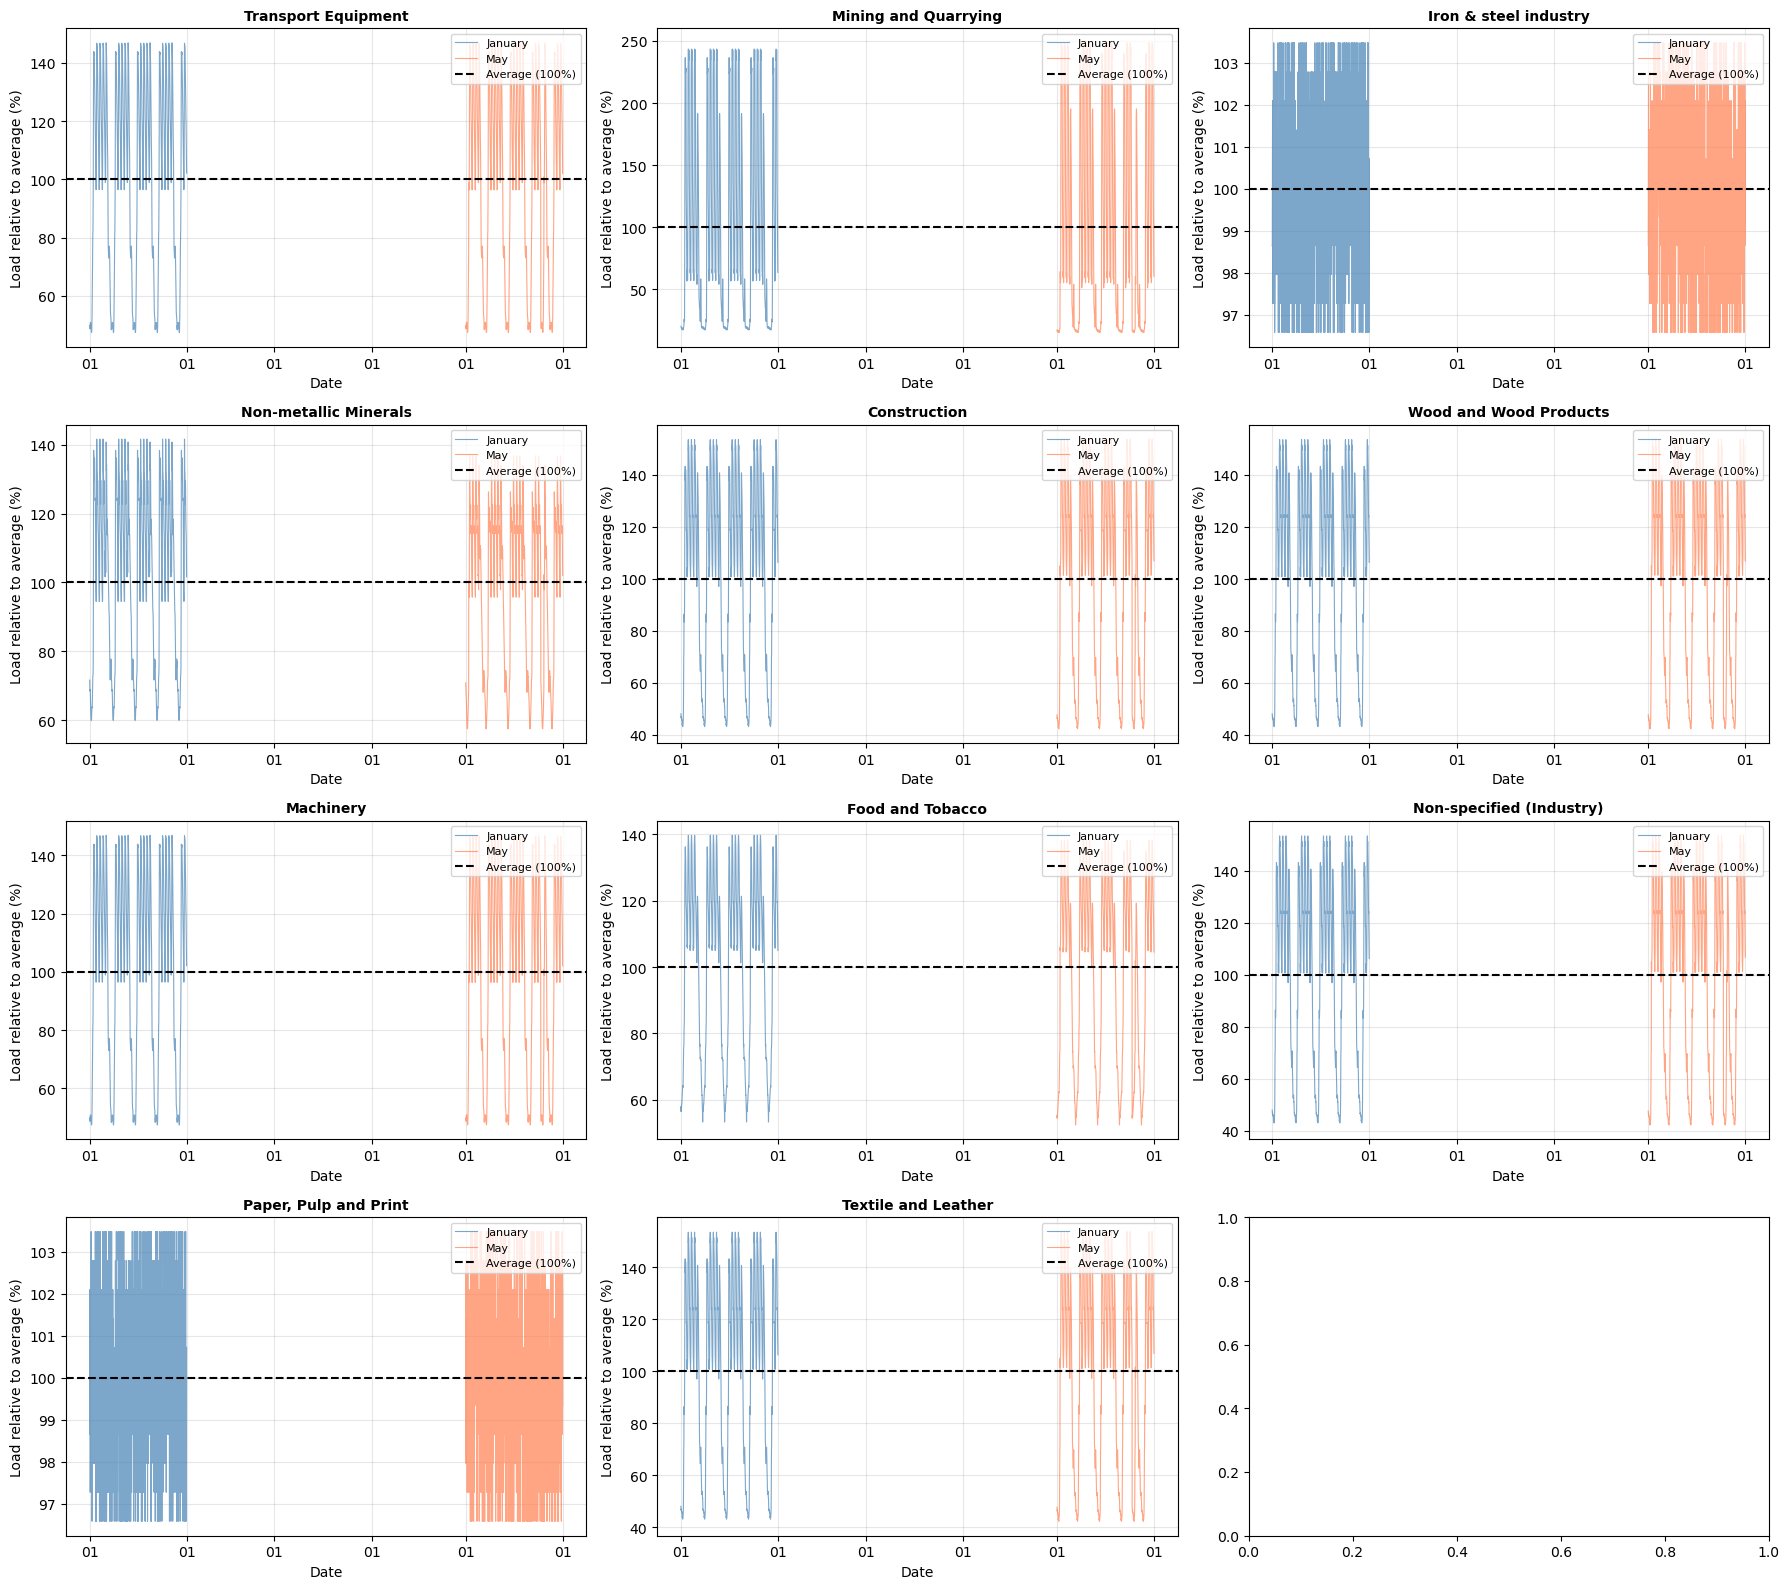


SUMMARY: Load Profile Variation for All Industries

Transport Equipment           
  January: Min= 47.4%, Max=146.9%, Range= 99.6%
  May:     Min= 47.4%, Max=146.8%, Range= 99.4%

Mining and Quarrying          
  January: Min= 17.4%, Max=243.4%, Range=226.0%
  May:     Min= 15.3%, Max=248.4%, Range=233.1%

Iron & steel industry         
  January: Min= 96.6%, Max=103.5%, Range=  6.9%
  May:     Min= 96.6%, Max=103.5%, Range=  6.9%

Non-metallic Minerals         
  January: Min= 60.0%, Max=141.6%, Range= 81.6%
  May:     Min= 57.6%, Max=136.7%, Range= 79.2%

Construction                  
  January: Min= 43.1%, Max=153.4%, Range=110.4%
  May:     Min= 42.3%, Max=153.7%, Range=111.4%

Wood and Wood Products        
  January: Min= 43.1%, Max=153.4%, Range=110.4%
  May:     Min= 42.3%, Max=153.7%, Range=111.4%

Machinery                     
  January: Min= 47.4%, Max=146.9%, Range= 99.6%
  May:     Min= 47.4%, Max=146.8%, Range= 99.4%

Food and Tobacco              
  January: Min= 53.3

In [7]:
# Extract January and May
jan_hours = date_range.month == 1
may_hours = date_range.month == 5

# Create plot
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, (_, row) in enumerate(df.iterrows()):
    ax = axes[idx]
    values = np.array(row["values"])

    # Calculate average (mean value)
    avg_value = np.mean(values)

    # Convert to percentage deviation from average (100% = average)
    values_pct = (values / avg_value) * 100

    # Extract January and May
    jan_values = values_pct[jan_hours]
    may_values = values_pct[may_hours]

    jan_dates = date_range[jan_hours]
    may_dates = date_range[may_hours]

    # Plot January
    ax.plot(
        jan_dates,
        jan_values,
        linewidth=0.8,
        label="January",
        color="steelblue",
        alpha=0.7,
    )

    # Plot May
    ax.plot(may_dates, may_values, linewidth=0.8, label="May", color="coral", alpha=0.7)

    # Plot average line at 100%
    ax.axhline(
        y=100, color="black", linestyle="--", linewidth=1.5, label="Average (100%)"
    )

    # Add title and labels
    ax.set_title(f"{row['industry_branch']}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Load relative to average (%)")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

    # Format x-axis
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d"))

    # Add vertical line to separate months visually
    if idx == 0:
        print(f"\nStats for {row['industry_branch']}:")
        print(f"  Average normalized value: {avg_value:.8f}")
        print(f"  January - Min: {jan_values.min():.1f}%, Max: {jan_values.max():.1f}%")
        print(f"  May - Min: {may_values.min():.1f}%, Max: {may_values.max():.1f}%")

plt.tight_layout()
# plt.savefig('industry_load_variation_jan_may.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics for all industries
print("\n" + "=" * 80)
print("SUMMARY: Load Profile Variation for All Industries")
print("=" * 80)

for _, row in df.iterrows():
    values = np.array(row["values"])
    avg_value = np.mean(values)
    values_pct = (values / avg_value) * 100

    jan_values = values_pct[jan_hours]
    may_values = values_pct[may_hours]

    print(f"\n{row['industry_branch']:30s}")
    print(
        f"  January: Min={jan_values.min():5.1f}%, Max={jan_values.max():5.1f}%, Range={jan_values.max() - jan_values.min():5.1f}%"
    )
    print(
        f"  May:     Min={may_values.min():5.1f}%, Max={may_values.max():5.1f}%, Range={may_values.max() - may_values.min():5.1f}%"
    )

In [8]:
industry_category_to_profile = {
    "Electric arc": "Iron & steel industry",
    "DRI + Electric arc": "Iron & steel industry",
    "Integrated steelworks": "Iron & steel industry",
    "HVC": "Non-specified (Industry)",
    "HVC (mechanical recycling)": "Non-specified (Industry)",
    "HVC (chemical recycling)": "Non-specified (Industry)",
    "Ammonia": "Non-specified (Industry)",
    "Chlorine": "Non-specified (Industry)",
    "Methanol": "Non-specified (Industry)",
    "Other chemicals": "Non-specified (Industry)",
    "Pharmaceutical products etc.": "Non-specified (Industry)",
    "Cement": "Non-metallic Minerals",
    "Ceramics & other NMM": "Non-metallic Minerals",
    "Glass production": "Non-metallic Minerals",
    "Pulp production": "Paper, Pulp and Print",
    "Paper production": "Paper, Pulp and Print",
    "Printing and media reproduction": "Paper, Pulp and Print",
    "Food, beverages and tobacco": "Food and Tobacco",
    "Alumina production": "Iron & steel industry",
    "Aluminium - primary production": "Iron & steel industry",
    "Aluminium - secondary production": "Iron & steel industry",
    "Other non-ferrous metals": "Non-specified (Industry)",
    "Transport equipment": "Transport Equipment",
    "Machinery equipment": "Machinery",
    "Textiles and leather": "Textile and Leather",
    "Wood and wood products": "Wood and Wood Products",
    "Other industrial sectors": "Non-specified (Industry)",
}

In [9]:
# KIT data
# unfortunately the industry sectors are not known

In [10]:
df_2016 = pd.read_csv(
    "/home/julian-geis/Documents/06_PhD/02Flexibility/data/industry_load/3899018/LoadProfile_20IPs_2016.csv",
    sep=";",
    decimal=".",
    skiprows=1,
    parse_dates=[0],
    index_col=0,
)
df_2017 = pd.read_csv(
    "/home/julian-geis/Documents/06_PhD/02Flexibility/data/industry_load/3899018/LoadProfile_30IPs_2017.csv",
    sep=";",
    decimal=".",
    skiprows=1,
    parse_dates=[0],
    index_col=0,
)

In [11]:
df_2016.head()

,LG 1,LG 2,LG 3,LG 4,LG 5,LG 6,LG 7,LG 8,LG 9,LG 10,LG 11,LG 12,LG 13,LG 14,LG 15,LG 16,LG 17,LG 18,LG 19,LG 20
Time stamp,,,,,,,,,,,,,,,,,,,,
01.01.2016 00:15:00,39,332.16,10.552,416.0,13.12,0.12,6.0,120,70,38.52,0.0,27.400,29.6,65.0,2462.4,6.200,0.96,25.8,11.46,220
01.01.2016 00:30:00,41,321.36,10.300,418.4,13.12,0.24,6.0,116,74,39.36,0.0,25.448,30.4,66.0,2462.4,6.200,0.90,34.2,11.32,224
01.01.2016 00:45:00,39,336.48,10.348,419.6,13.76,0.12,6.0,108,68,39.84,0.0,27.000,30.4,68.0,2459.2,5.876,0.90,38.4,11.62,226
01.01.2016 01:00:00,40,319.20,10.600,422.0,13.44,0.12,8.0,112,80,39.24,0.0,27.552,29.6,67.0,2451.2,6.200,1.02,19.8,9.40,220
01.01.2016 01:15:00,39,322.80,10.148,418.8,13.44,0.24,6.0,120,72,38.52,272.0,24.900,31.2,66.0,2436.8,6.200,0.90,16.8,10.58,224


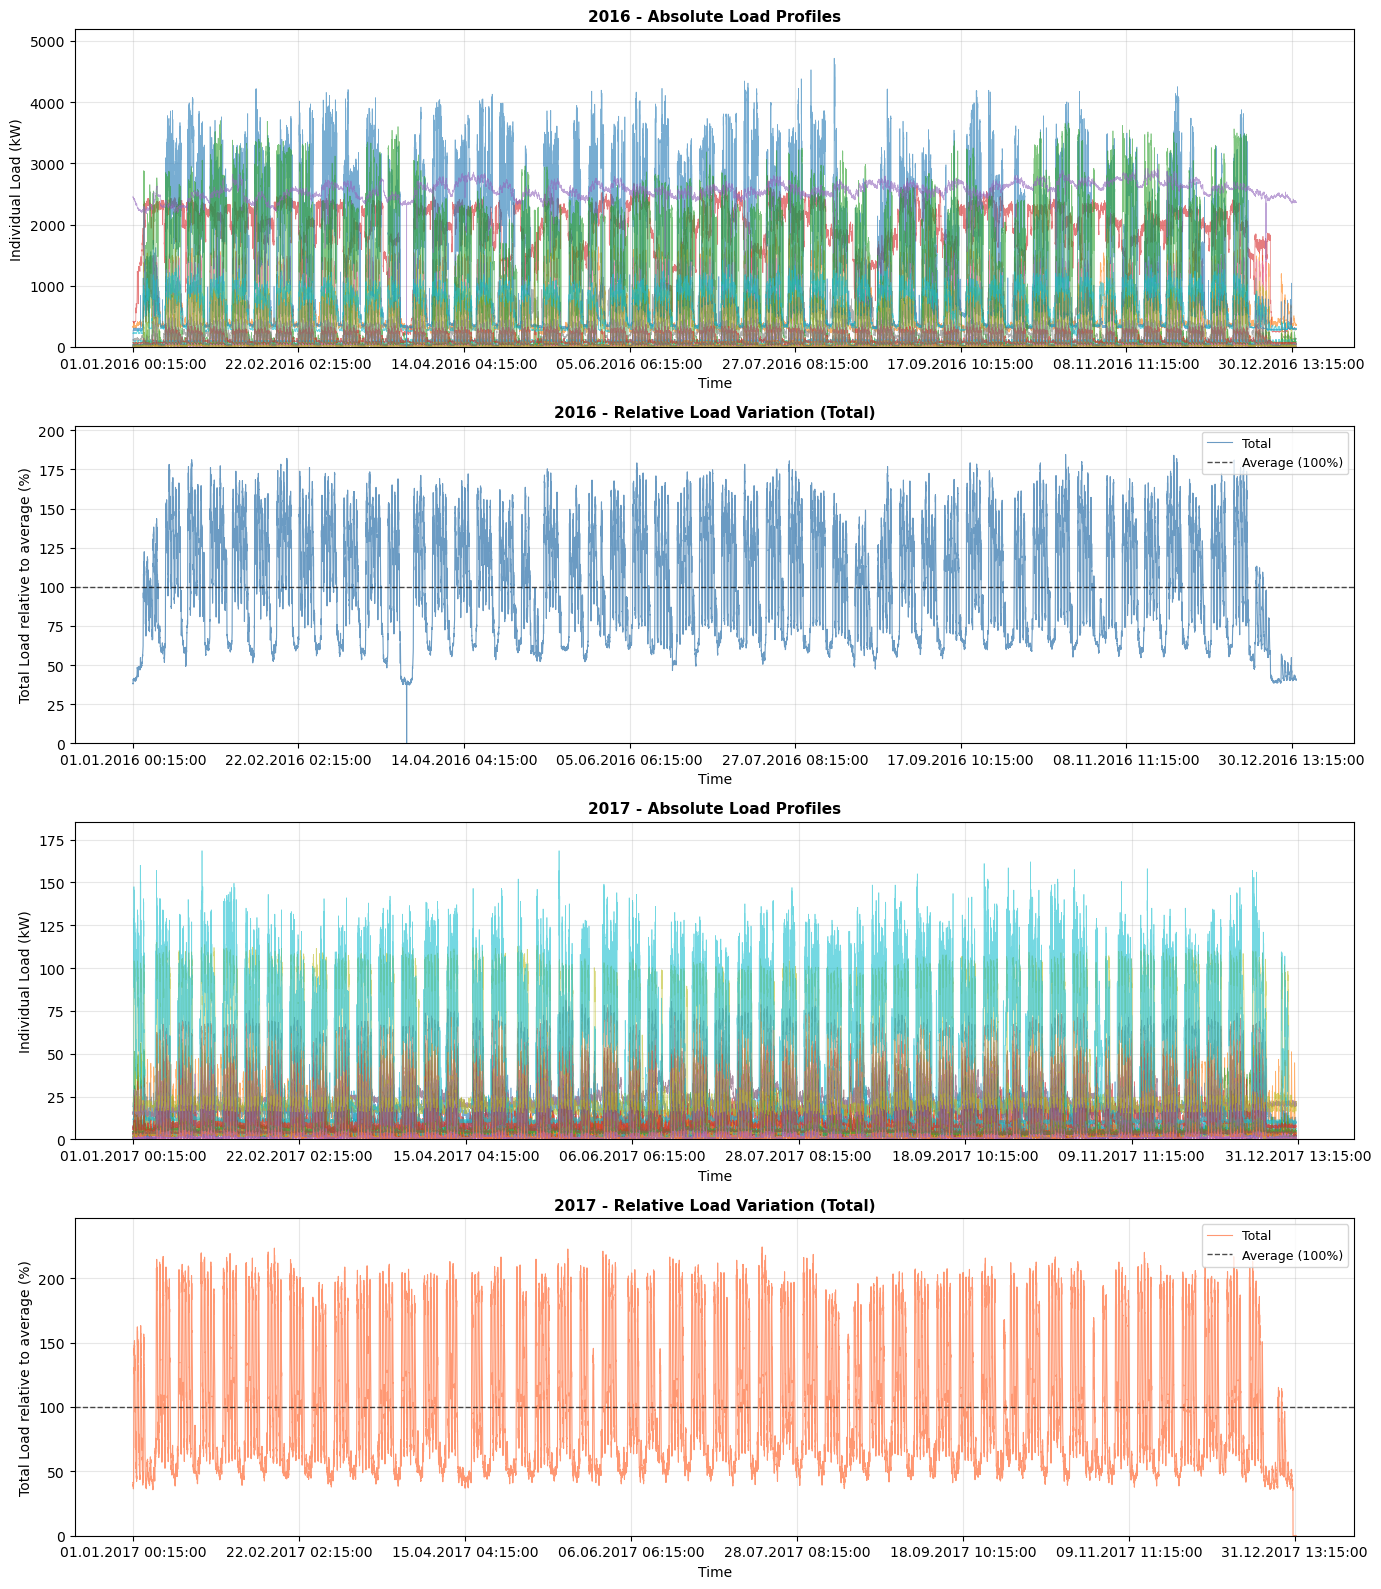

In [12]:
# Get all LG columns
lg_cols_2016 = [col for col in df_2016.columns if col.startswith("LG")]
lg_cols_2017 = [col for col in df_2017.columns if col.startswith("LG")]

# Calculate totals
df_2016["Total"] = df_2016[lg_cols_2016].sum(axis=1)
df_2017["Total"] = df_2017[lg_cols_2017].sum(axis=1)

# Create figure with 4 rows, 1 column
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# ========== Plot 1: 2016 Absolute ==========
ax1 = axes[0]
df_2016[lg_cols_2016].plot(ax=ax1, linewidth=0.5, alpha=0.6, legend=False)
ax1.set_ylabel("Individual Load (kW)", fontsize=10)
ax1.set_xlabel("Time", fontsize=10)
ax1.set_title("2016 - Absolute Load Profiles", fontweight="bold", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, df_2016[lg_cols_2016].max().max() * 1.1])

# ========== Plot 2: 2016 Relative (Total Load) ==========
ax2 = axes[1]
avg_total_2016 = df_2016["Total"].mean()
pct_total_2016 = (df_2016["Total"] / avg_total_2016) * 100
pct_total_2016.plot(ax=ax2, linewidth=0.8, alpha=0.8, color="steelblue")
ax2.axhline(
    y=100, color="black", linestyle="--", linewidth=1, label="Average (100%)", alpha=0.7
)
ax2.set_ylabel("Total Load relative to average (%)", fontsize=10)
ax2.set_xlabel("Time", fontsize=10)
ax2.set_title("2016 - Relative Load Variation (Total)", fontweight="bold", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right", fontsize=9)
ax2.set_ylim([0, pct_total_2016.max() * 1.1])

# ========== Plot 3: 2017 Absolute ==========
ax3 = axes[2]
df_2017[lg_cols_2017].plot(ax=ax3, linewidth=0.5, alpha=0.6, legend=False)
ax3.set_ylabel("Individual Load (kW)", fontsize=10)
ax3.set_xlabel("Time", fontsize=10)
ax3.set_title("2017 - Absolute Load Profiles", fontweight="bold", fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, df_2017[lg_cols_2017].max().max() * 1.1])

# ========== Plot 4: 2017 Relative (Total Load) ==========
ax4 = axes[3]
avg_total_2017 = df_2017["Total"].mean()
pct_total_2017 = (df_2017["Total"] / avg_total_2017) * 100
pct_total_2017.plot(ax=ax4, linewidth=0.8, alpha=0.8, color="coral")
ax4.axhline(
    y=100, color="black", linestyle="--", linewidth=1, label="Average (100%)", alpha=0.7
)
ax4.set_ylabel("Total Load relative to average (%)", fontsize=10)
ax4.set_xlabel("Time", fontsize=10)
ax4.set_title("2017 - Relative Load Variation (Total)", fontweight="bold", fontsize=11)
ax4.grid(True, alpha=0.3)
ax4.legend(loc="upper right", fontsize=9)
ax4.set_ylim([0, pct_total_2017.max() * 1.1])

plt.tight_layout()
plt.show()

# TUB data

In [13]:
dir = "/home/julian-geis/Documents/06_PhD/02Flexibility/data/industry_load/TUB Subsector load profiles (Branchenlastprofile - BLP)/TUB Subsector load profiles (Branchenlastprofile - BLP)/"
test = pd.read_csv(
    dir + "WZ17_Papierherstellung Weighted German Average  2014.csv",
    sep=";",
    decimal=",",
    skiprows=[1],
)

In [14]:
test

,Unnamed: 0,Mean_Value,0.05_Quantile,0.95_Quantile
0,2014-01-01 00:15:00,0.018685,0.008123,0.058438
1,2014-01-01 00:30:00,0.018705,0.008149,0.058552
2,2014-01-01 00:45:00,0.018725,0.008176,0.058666
3,2014-01-01 01:00:00,0.018745,0.008202,0.058774
4,2014-01-01 01:15:00,0.018765,0.008228,0.058878
...,...,...,...,...
35034,2014-12-31 22:45:00,0.016750,0.006107,0.050728
35035,2014-12-31 23:00:00,0.016709,0.006090,0.050579
35036,2014-12-31 23:15:00,0.016668,0.006072,0.050432
35037,2014-12-31 23:30:00,0.016628,0.006055,0.050287


# Temporal industry loads implementation

In [15]:
def download_ffe_load_profiles():
    """Download normalized industry load profiles from FfE."""
    url = "https://api.opendata.ffe.de"
    params = {"id_opendata": 59}

    # Check API health
    response = requests.get(url + "/health")
    if response.status_code != 200:
        raise ConnectionError(f"API not available. Status: {response.status_code}")

    # Fetch data
    response = requests.get(url + "/opendata", params=params)
    if response.status_code != 200:
        raise ConnectionError(f"Request failed. Status: {response.status_code}")

    data = response.json()
    print(f"Downloaded FfE data: {data['title']}")

    # Map internal_id to profile names
    id_to_profile = {
        0: "Industry (total)",
        1: "Iron & steel industry",
        4: "Non-metallic Minerals",
        5: "Transport Equipment",
        6: "Machinery",
        7: "Mining and Quarrying",
        8: "Food and Tobacco",
        9: "Paper, Pulp and Print",
        10: "Wood and Wood Products",
        11: "Construction",
        12: "Textile and Leather",
        13: "Non-specified (Industry)",
    }

    # Create hourly timestamps for 2017
    timestamps = pd.date_range("2017-01-01", "2017-12-31 23:00:00", freq="h")

    # Parse the data into a DataFrame
    profiles_dict = {}
    for row in data["data"]:
        # Data is already parsed as lists, not JSON strings
        internal_id = row["internal_id"][0]  # Extract first element from list [5]
        values = row["values"]  # Already a list

        if internal_id in id_to_profile:
            profile_name = id_to_profile[internal_id]
            profiles_dict[profile_name] = values

    profiles_df = pd.DataFrame(profiles_dict, index=timestamps)

    print(f"Loaded profiles: {list(profiles_df.columns)}")
    return profiles_df


def create_nodal_electricity_profiles(
    nodal_df, nodal_production, sector_ratios, snapshots
):
    """Create hourly electricity demand profiles for each node."""

    # Industry category to FfE profile mapping (updated to match correct profile names)
    industry_category_to_profile = {
        "Electric arc": "Iron & steel industry",
        "DRI + Electric arc": "Iron & steel industry",
        "Integrated steelworks": "Iron & steel industry",
        "HVC": "Non-specified (Industry)",
        "HVC (mechanical recycling)": "Non-specified (Industry)",
        "HVC (chemical recycling)": "Non-specified (Industry)",
        "Ammonia": "Non-specified (Industry)",
        "Chlorine": "Non-specified (Industry)",
        "Methanol": "Non-specified (Industry)",
        "Other chemicals": "Non-specified (Industry)",
        "Pharmaceutical products etc.": "Non-specified (Industry)",
        "Cement": "Non-metallic Minerals",
        "Ceramics & other NMM": "Non-metallic Minerals",
        "Glass production": "Non-metallic Minerals",
        "Pulp production": "Paper, Pulp and Print",
        "Paper production": "Paper, Pulp and Print",
        "Printing and media reproduction": "Paper, Pulp and Print",
        "Food, beverages and tobacco": "Food and Tobacco",
        "Alumina production": "Iron & steel industry",
        "Aluminium - primary production": "Iron & steel industry",
        "Aluminium - secondary production": "Iron & steel industry",
        "Other non-ferrous metals": "Non-specified (Industry)",
        "Transport equipment": "Transport Equipment",
        "Machinery equipment": "Machinery",
        "Textiles and leather": "Textile and Leather",
        "Wood and wood products": "Wood and Wood Products",
        "Other industrial sectors": "Non-specified (Industry)",
    }

    # Download FfE profiles
    print("Downloading FfE industry load profiles...")
    ffe_profiles = download_ffe_load_profiles()

    # Initialize result DataFrame
    nodal_profiles = pd.DataFrame(index=snapshots, columns=nodal_df.index, dtype=float)

    # For each node, create weighted profile
    for node in nodal_production.index:
        country = node[:2]

        # Get electricity demand by sector for this node (MWh/tMaterial)
        elec_ratios = sector_ratios[country].loc["elec"]

        # Get production by sector for this node (Mton/a)
        production = nodal_production.loc[node]

        # Calculate electricity demand by sector (TWh/a)
        sector_demands = elec_ratios * production / 1e6  # Convert MWh to TWh

        # Create weighted profile (8760 hours from reference year)
        node_profile = pd.Series(0.0, index=ffe_profiles.index)
        total_weight = 0

        for sector, demand in sector_demands.items():
            if demand > 0 and sector in industry_category_to_profile:
                profile_name = industry_category_to_profile[sector]
                if profile_name in ffe_profiles.columns:
                    node_profile += ffe_profiles[profile_name] * demand
                    total_weight += demand
                else:
                    print(
                        f"Profile '{profile_name}' not found in FfE data for sector '{sector}'"
                    )

        if total_weight == 0:
            print(f"No valid profile for node {node}, using flat profile")
            node_profile[:] = 1.0 / len(node_profile)
        else:
            # Normalize profile so it sums to 1
            node_profile = node_profile / node_profile.sum()

        # Map profile to snapshots with correct day-of-week alignment
        hourly_profile = map_profile_to_snapshots(node_profile, snapshots)

        # Scale to annual demand (convert TWh/a to MW hourly values)
        annual_demand_twh = nodal_df.loc[node, "electricity"]
        annual_demand_mwh = annual_demand_twh * 1e6  # TWh to MWh

        # Scale normalized profile to match annual demand
        nodal_profiles[node] = hourly_profile * annual_demand_mwh

    return nodal_profiles


def map_profile_to_snapshots(reference_profile, snapshots):
    """Map a 2017 reference profile to the snapshot period, matching day-of-week and hour."""

    mapped_profile = pd.Series(index=snapshots, dtype=float)

    for timestamp in snapshots:
        # Find hours in reference profile with same day-of-week and hour
        ref_candidates = reference_profile[
            (reference_profile.index.dayofweek == timestamp.dayofweek)
            & (reference_profile.index.hour == timestamp.hour)
        ]

        if len(ref_candidates) > 0:
            # Use mean of matching hours (typically ~52 weeks in a year)
            mapped_profile[timestamp] = ref_candidates.mean()
        else:
            # Fallback: use hour-of-day average
            ref_candidates = reference_profile[
                reference_profile.index.hour == timestamp.hour
            ]
            mapped_profile[timestamp] = (
                ref_candidates.mean()
                if len(ref_candidates) > 0
                else reference_profile.mean()
            )

    # CRITICAL: Renormalize to ensure it sums to 1
    mapped_profile = mapped_profile / mapped_profile.sum()

    return mapped_profile

In [16]:
load_profiles = download_ffe_load_profiles()

Downloaded FfE data: Normed Industrial Electrical Load Profile (Germany)
Loaded profiles: ['Transport Equipment', 'Mining and Quarrying', 'Food and Tobacco', 'Machinery', 'Wood and Wood Products', 'Construction', 'Textile and Leather', 'Iron & steel industry', 'Non-metallic Minerals', 'Non-specified (Industry)', 'Paper, Pulp and Print']


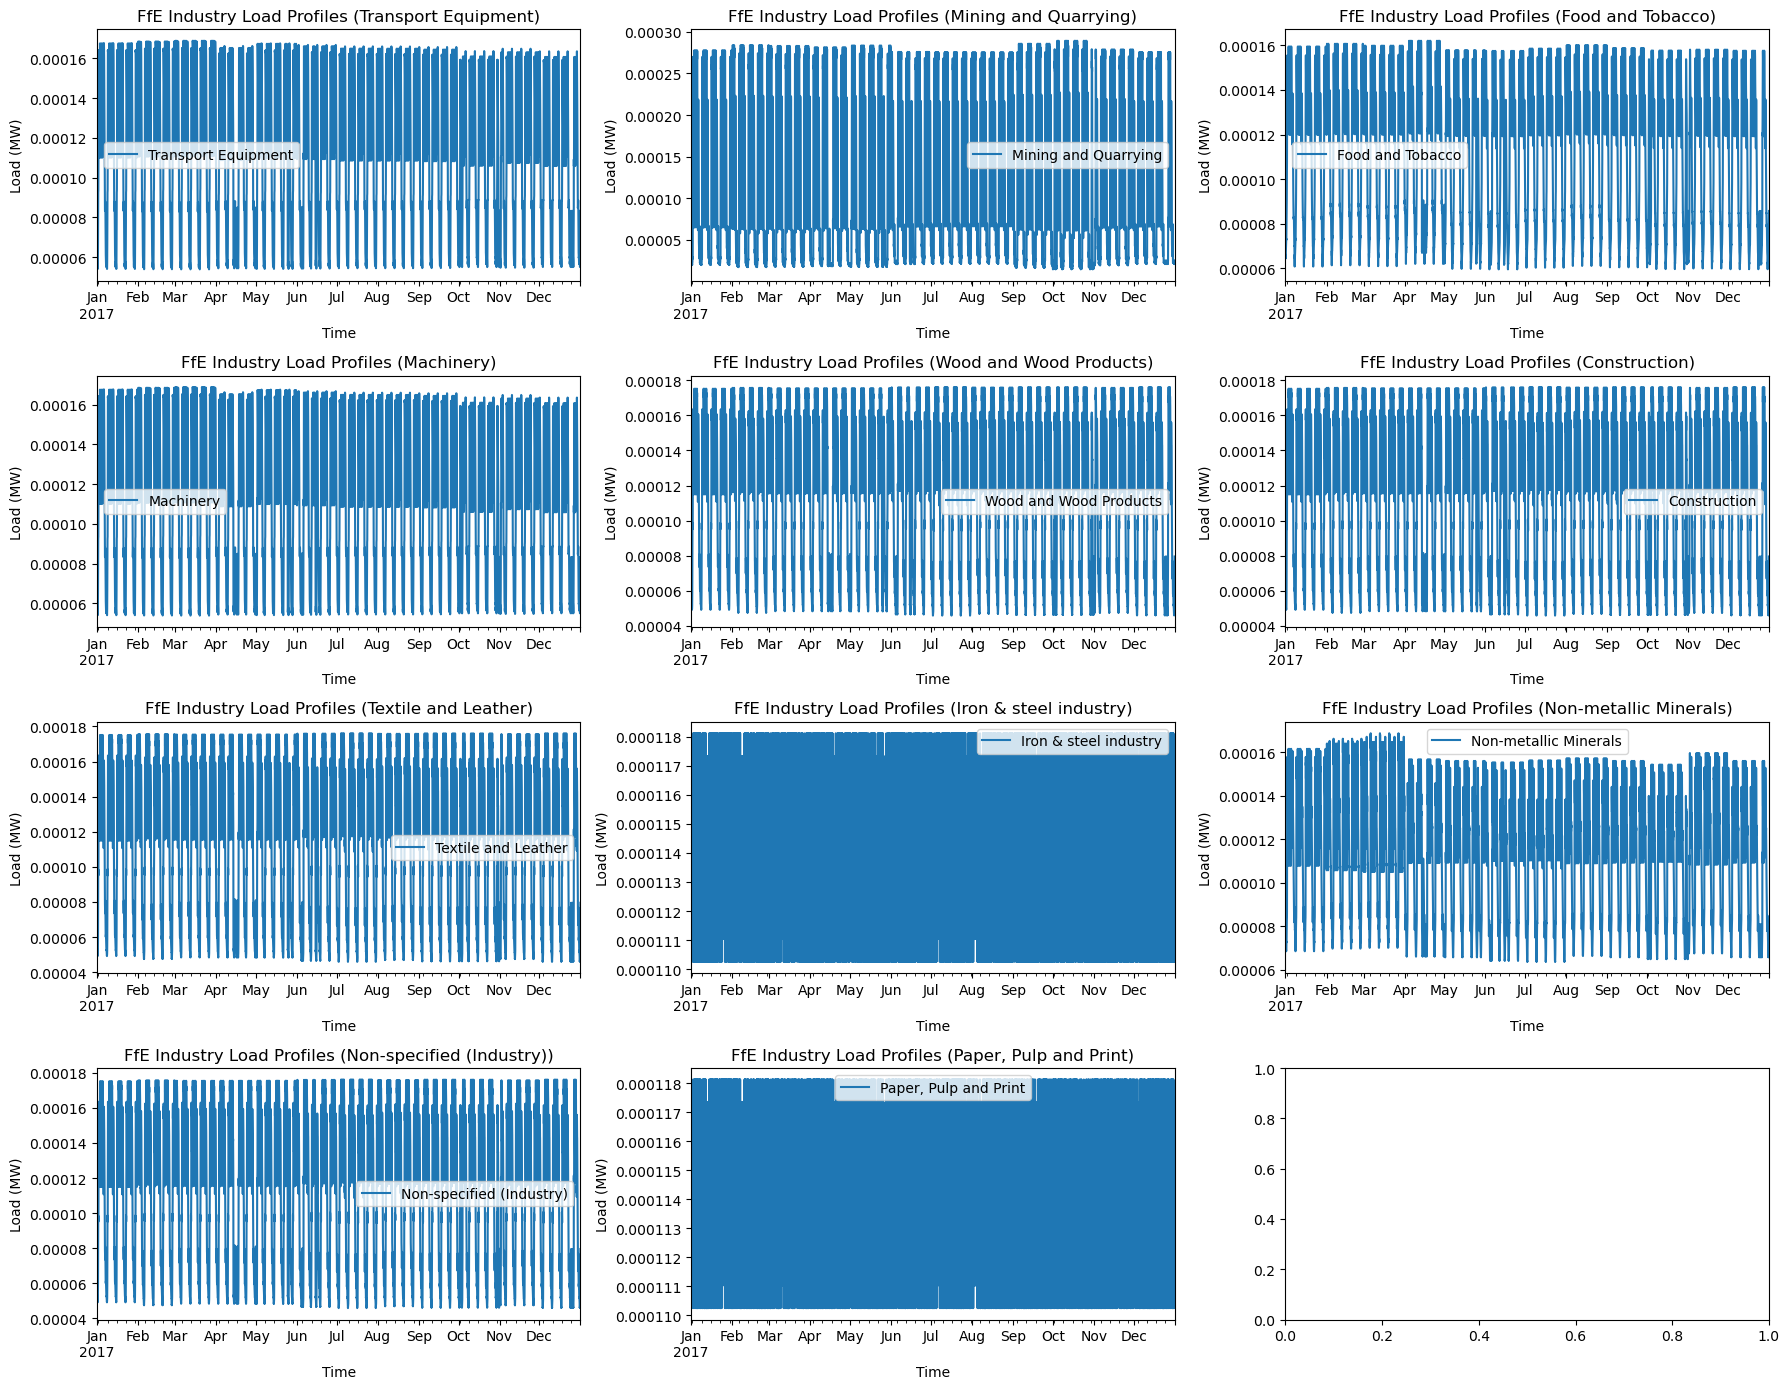

In [17]:
fig, ax = plt.subplots(4, 3, figsize=(18, 14))
for i, column in enumerate(load_profiles.columns):
    current_ax = ax[i // 3, i % 3]
    load_profiles[column].plot(ax=current_ax, label=column)
    current_ax.set_title(f"FfE Industry Load Profiles ({column})")
    current_ax.set_xlabel("Time")
    current_ax.set_ylabel("Load (MW)")
    current_ax.legend()

plt.tight_layout()
plt.show()

# DSM implementation

Index(['gas', 'wind'], dtype='object', name='Generator')
Index(['DE'], dtype='object', name='Bus')


STEP 1: Optimizing network WITHOUT DSM (baseline)...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1440 primals, 3600 duals
Objective: 2.59e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.
Index(['DSM_increase_sink', 'DSM_debt'], dtype='object', name='Store')
Index(['gas', 'wind'], dtype='object', name='Generator')
Index(['DE', 'DSM_increase_bus', 'DSM_debt_bus'], dtype='object', name='Bus')
Index(['DSM_ramp_up', 'DSM_ramp_down', 'DSM_compensate'], dtype='object', name='Link')


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-zay_k6pc has 3600 rows; 1440 cols; 4320 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [8e+01, 8e+01]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+04]
Presolving model
0 rows, 0 cols, 0 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve : Reductions: rows 0(-3600); columns 0(-1440); elements 0(-4320) - Reduced to empty
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-zay_k6pc
Model status        : Optimal
Objective value     :  2.5913774986e+08
P-D objective error :  5.7502857739e-17
HiGHS run time      :          0.00
Writing the solution to /tmp/linopy-solve-lll3dtq7.sol
✓ Optimization completed
  Total cost: 259,137,749.86 EUR
  Gas generation: 3,239,221.87 MWh
  Wind generation: 5,400,778.13 MWh

STEP 2: Optimizing network WITH DSM...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.06s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 6480 primals, 13709 duals
Objective: 2.45e+08
Solver model: available
Solver message: Optimal



✓ Successfully added 29 daily reset constraints
Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-qc6vnp7o has 13709 rows; 6480 cols; 20909 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [1e+01, 8e+01]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 4e+04]
Presolving model
2160 rows, 4841 cols, 7692 nonzeros  0s
1440 rows, 4121 cols, 6252 nonzeros  0s
Dependent equations search running on 1440 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
1440 rows, 4121 cols, 6252 nonzeros  0s
Presolve : Reductions: rows 1440(-12269); columns 4121(-2359); elements 6252(-14657)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s
       2326     2.4511269867e+08 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name         

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance, Store-dsm_daily_reset were not assigned to the network.


✓ Optimization completed
  Total cost: 245,112,698.67 EUR
  Gas generation: 3,003,547.90 MWh
  Wind generation: 5,860,587.34 MWh

COMPARISON: WITH vs WITHOUT DSM

💰 COST SAVINGS:
  Without DSM: 259,137,749.86 EUR
  With DSM:    245,112,698.67 EUR
  Savings:     14,025,051.19 EUR (5.41%)

🏭 GAS GENERATION:
  Without DSM: 3,239,221.87 MWh
  With DSM:    3,003,547.90 MWh
  Reduction:   235,673.98 MWh (7.28%)

🌬️  WIND GENERATION:
  Without DSM: 5,400,778.13 MWh
  With DSM:    5,860,587.34 MWh
  Increase:    459,809.21 MWh (8.51%)

📊 KEY INSIGHT:
  DSM reduces total system cost by 5.4%
  This is achieved by:
    - Reducing expensive gas generation by 7.3%
    - Increasing cheap wind utilization by 8.5%

Available links: ['DSM_ramp_up', 'DSM_ramp_down', 'DSM_compensate']
Available stores: ['DSM_increase_sink', 'DSM_debt']

DSM USAGE SUMMARY

RAMP UP (load increase - no compensation needed):
  Hours used: 73
  Total energy: 224135.24 MWh
  Max power: 8738.67 MW
  Use case: Consume cheap/abun

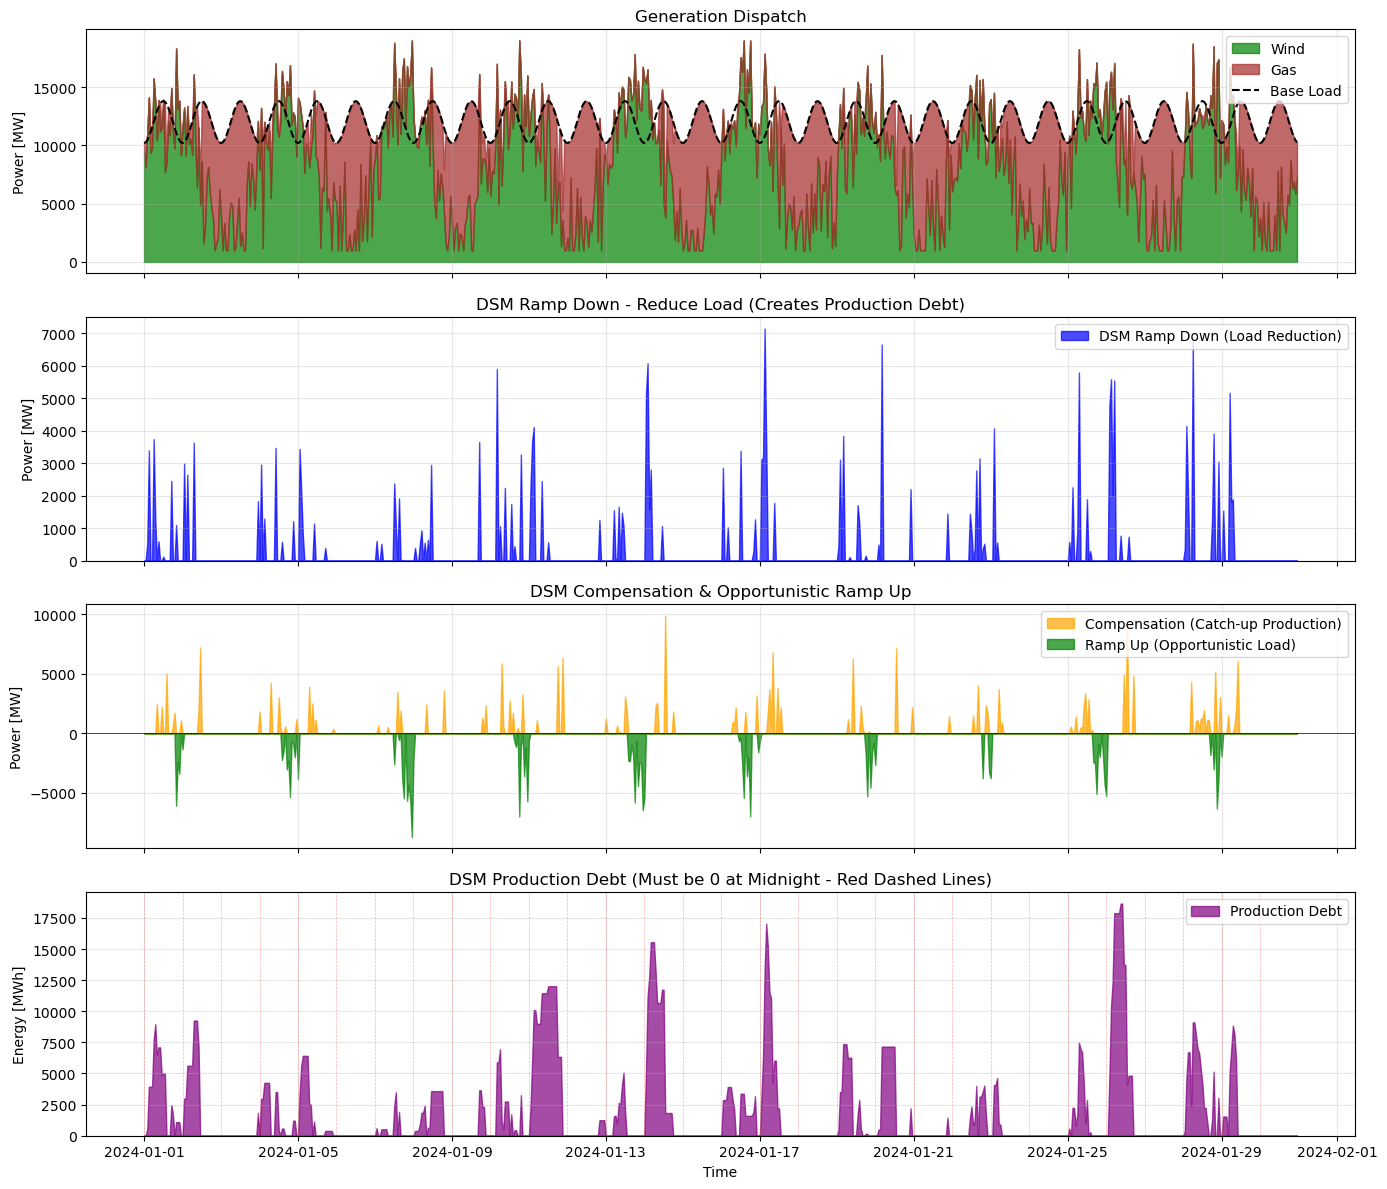

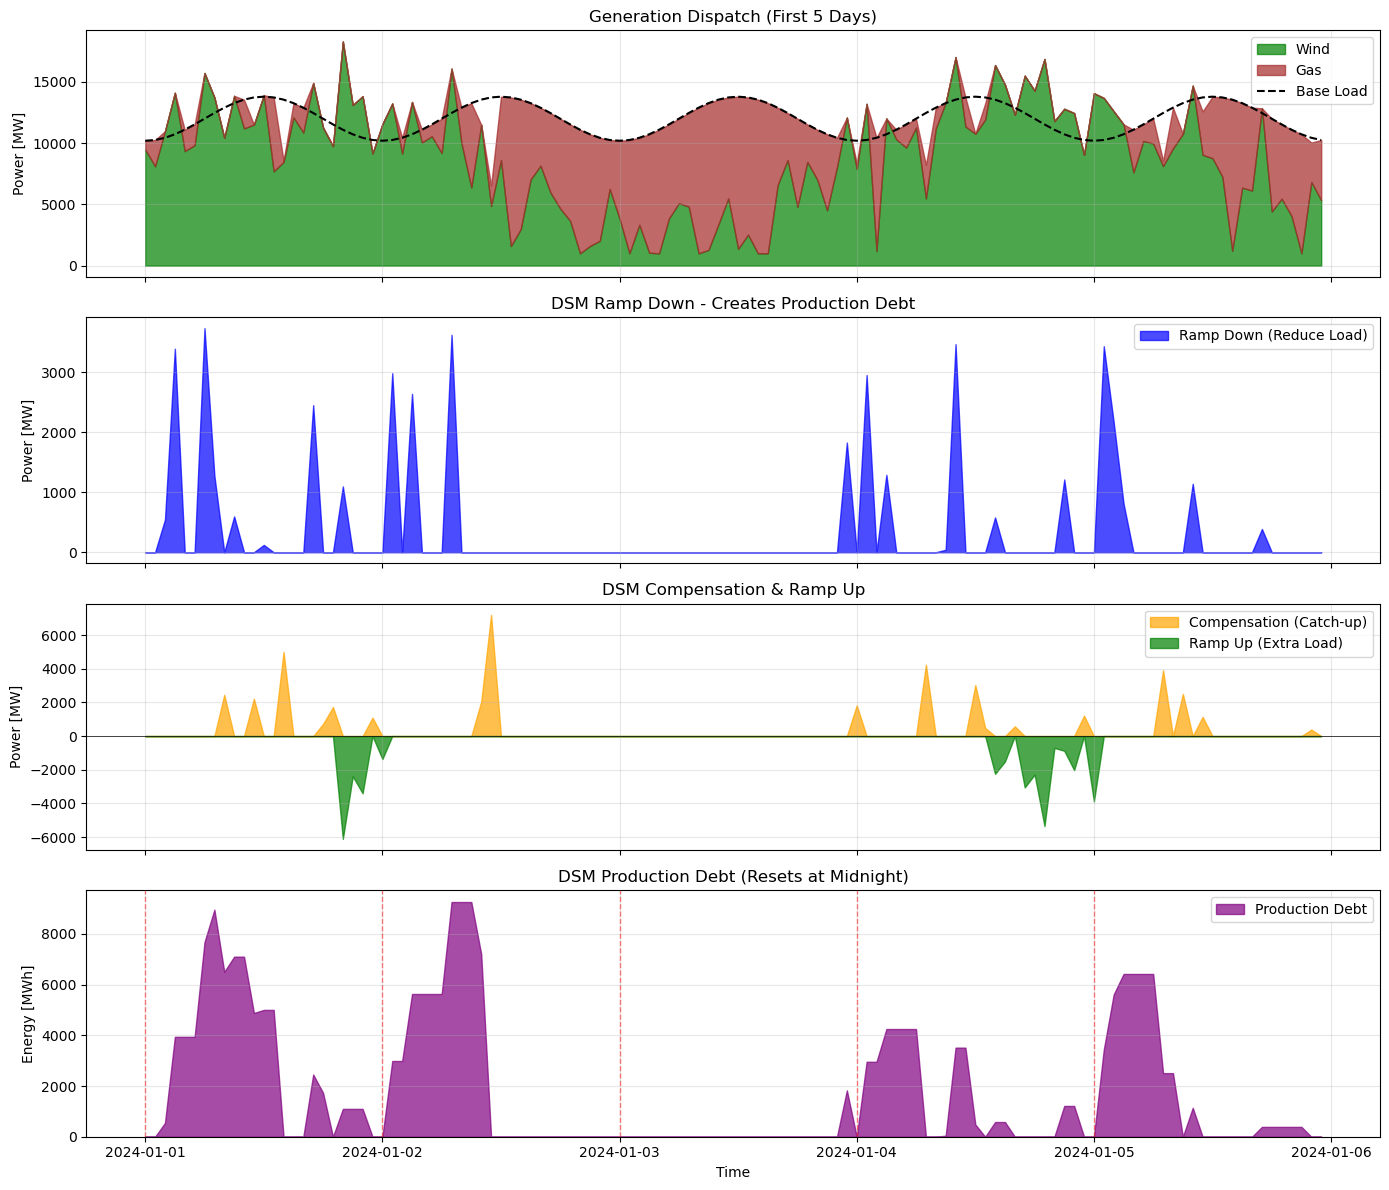

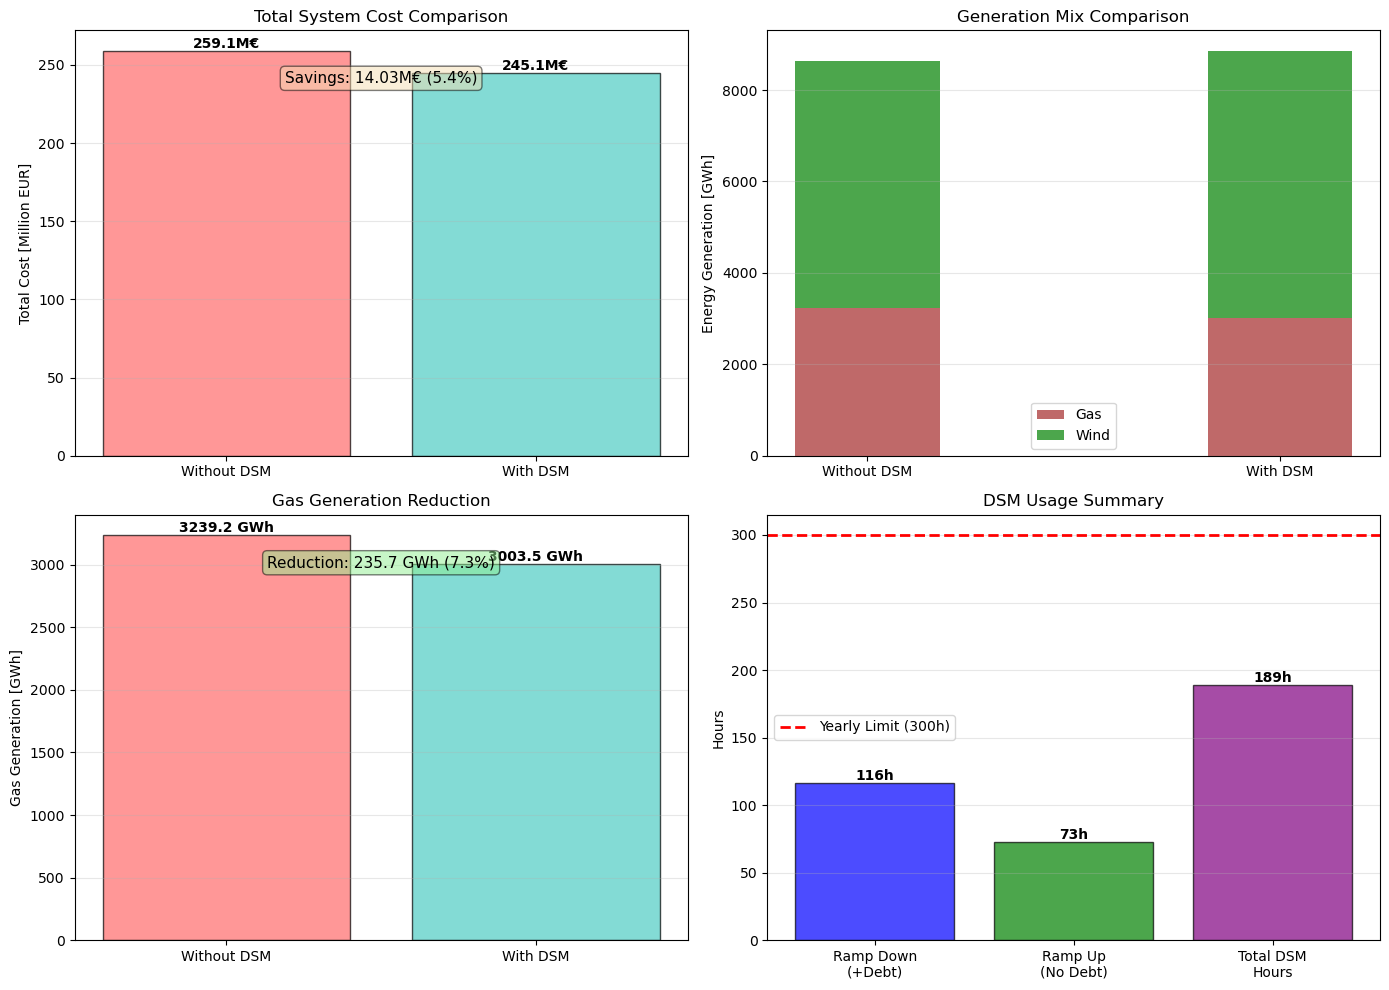

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa

# Create network
network = pypsa.Network()

# Time range: 30 days, hourly resolution
snapshots = pd.date_range("2024-01-01", periods=30 * 24, freq="h")
network.set_snapshots(snapshots)

# Add single bus
network.add("Bus", "DE", carrier="AC")

# Add generators
# 1. Gas generator - expensive but flexible
network.add(
    "Generator",
    "gas",
    bus="DE",
    p_nom=15000,  # 15 GW capacity
    marginal_cost=80,  # EUR/MWh
    carrier="gas",
)

# 2. Wind generator - cheap but variable
network.add(
    "Generator",
    "wind",
    bus="DE",
    p_nom=20000,  # 20 GW capacity
    marginal_cost=0,  # EUR/MWh
    carrier="wind",
)

# Create realistic wind profile (more variable, with low periods)
np.random.seed(42)
wind_base = np.sin(np.arange(len(snapshots)) * 2 * np.pi / (24 * 3)) * 0.3 + 0.4
wind_noise = np.random.normal(0, 0.15, len(snapshots))
wind_profile = np.clip(wind_base + wind_noise, 0.05, 0.95)
network.generators_t.p_max_pu["wind"] = wind_profile

# Add base load (industry + other)
# Base load with daily pattern: higher during day, lower at night
base_load = 12000  # 12 GW average
daily_pattern = (
    np.sin((np.arange(len(snapshots)) % 24) * 2 * np.pi / 24 - np.pi / 2) * 0.15 + 1
)
load_profile = base_load * daily_pattern
network.add("Load", "base_load", bus="DE", p_set=load_profile)

# DSM IMPLEMENTATION - CORRECTED LOGIC
# =====================================

# 1. RAMP UP (increase industry load, no compensation needed)
# Industry increases electricity consumption when power is cheap/abundant
# This is opportunistic - no debt created
network.add("Bus", "DSM_increase_bus", carrier="DSM")


# Store that immediately loses all energy (standing_loss=1.0 means 100% loss per hour)
network.add(
    "Store",
    "DSM_increase_sink",
    bus="DSM_increase_bus",
    e_nom=40000,  # 10 GW * 4 hours
    e_initial=0,
    e_cyclic=False,
    standing_loss=1.0,  # 100% loss - energy disappears immediately
    capital_cost=0,
)

network.add(
    "Link",
    "DSM_ramp_up",
    bus0="DE",  # Takes power FROM grid
    bus1="DSM_increase_bus",  # Sends to store that loses it
    p_nom=10000,  # 10 GW
    efficiency=1.0,
    marginal_cost=-10,  # Benefit for consuming cheap power
    capital_cost=0,
    carrier="DSM ramp up",
)


# 2. RAMP DOWN (reduce industry load, MUST compensate within 24h)
# Industry reduces electricity consumption but production still needs to happen
# Creates "production debt" that must be paid back within 24 hours

# Create bus for debt tracking
network.add("Bus", "DSM_debt_bus", carrier="DSM")

# Store to track production debt
network.add(
    "Store",
    "DSM_debt",
    bus="DSM_debt_bus",
    e_nom=40000,  # 10 GW * 4 hours = 40 GWh
    e_initial=0,
    e_cyclic=True,
    standing_loss=0,
    capital_cost=0,
)

# Link: Ramp DOWN = reduce load, charges the debt store
network.add(
    "Link",
    "DSM_ramp_down",
    bus0="DE",  # Takes from grid
    bus1="DSM_debt_bus",  # Charges debt
    p_nom=10000,  # 10 GW
    efficiency=1.0,
    marginal_cost=20,  # Benefit from reducing load??
    capital_cost=0,
    carrier="DSM ramp down",
)

# Link: Compensate = increase load later to catch up, discharges debt
network.add(
    "Link",
    "DSM_compensate",
    bus0="DSM_debt_bus",  # Discharges debt
    bus1="DE",  # Adds load to grid
    p_nom=10000,  # 10 GW
    efficiency=1.0,
    marginal_cost=10,  # Cost of catch-up production
    capital_cost=0,
    carrier="DSM compensate",
)

# OPTIMIZATION WITH 24H CONSTRAINT
# =================================


def optimize_with_daily_reset(network):
    """
    Optimize with constraint that DSM debt must be zero at midnight
    PyPSA 0.35.1 compatible version
    """

    def add_constraints(n, snapshots):
        model = n.model

        try:
            # Access Store energy variable
            e = model["Store-e"]

            # Create constraints for each midnight (every 24 hours)
            midnight_snapshots = snapshots[24::24]

            # For each midnight, set debt to zero
            lhs = e.loc[midnight_snapshots, "DSM_debt"]

            # Add constraint
            model.add_constraints(lhs == 0, name="Store-dsm_daily_reset")
            print(
                f"✓ Successfully added {len(midnight_snapshots)} daily reset constraints"
            )

        except Exception as e:
            print(f"✗ Could not add constraints: {e}")
            print("  Continuing without midnight constraints...")

    # Run optimization with extra functionality
    network.optimize(extra_functionality=add_constraints)

    return network


# CREATE BASELINE WITHOUT DSM
# ============================
print("=" * 70)
print("STEP 1: Optimizing network WITHOUT DSM (baseline)...")
print("=" * 70)

network_no_dsm = pypsa.Network()
network_no_dsm.set_snapshots(snapshots)

# Add bus
network_no_dsm.add("Bus", "DE", carrier="AC")

# Add generators (same as main network)
network_no_dsm.add(
    "Generator", "gas", bus="DE", p_nom=15000, marginal_cost=80, carrier="gas"
)

network_no_dsm.add(
    "Generator", "wind", bus="DE", p_nom=20000, marginal_cost=0, carrier="wind"
)

network_no_dsm.generators_t.p_max_pu["wind"] = wind_profile

# Add base load (same as main network)
network_no_dsm.add("Load", "base_load", bus="DE", p_set=load_profile)

# Optimize without DSM
network_no_dsm.optimize()

# Get results
objective_no_dsm = network_no_dsm.objective
gas_no_dsm = network_no_dsm.generators_t.p["gas"].sum()
wind_no_dsm = network_no_dsm.generators_t.p["wind"].sum()

print("✓ Optimization completed")
print(f"  Total cost: {objective_no_dsm:,.2f} EUR")
print(f"  Gas generation: {gas_no_dsm:,.2f} MWh")
print(f"  Wind generation: {wind_no_dsm:,.2f} MWh")

# OPTIMIZE WITH DSM
# =================
print("\n" + "=" * 70)
print("STEP 2: Optimizing network WITH DSM...")
print("=" * 70)

optimize_with_daily_reset(network)

# Get results
objective_with_dsm = network.objective
gas_with_dsm = network.generators_t.p["gas"].sum()
wind_with_dsm = network.generators_t.p["wind"].sum()

print("✓ Optimization completed")
print(f"  Total cost: {objective_with_dsm:,.2f} EUR")
print(f"  Gas generation: {gas_with_dsm:,.2f} MWh")
print(f"  Wind generation: {wind_with_dsm:,.2f} MWh")

# COMPARISON
# ==========
print("\n" + "=" * 70)
print("COMPARISON: WITH vs WITHOUT DSM")
print("=" * 70)
cost_savings = objective_no_dsm - objective_with_dsm
cost_savings_pct = (cost_savings / objective_no_dsm) * 100
gas_reduction = gas_no_dsm - gas_with_dsm
gas_reduction_pct = (gas_reduction / gas_no_dsm) * 100
wind_increase = wind_with_dsm - wind_no_dsm
wind_increase_pct = (wind_increase / wind_no_dsm) * 100

print("\n💰 COST SAVINGS:")
print(f"  Without DSM: {objective_no_dsm:,.2f} EUR")
print(f"  With DSM:    {objective_with_dsm:,.2f} EUR")
print(f"  Savings:     {cost_savings:,.2f} EUR ({cost_savings_pct:.2f}%)")

print("\n🏭 GAS GENERATION:")
print(f"  Without DSM: {gas_no_dsm:,.2f} MWh")
print(f"  With DSM:    {gas_with_dsm:,.2f} MWh")
print(f"  Reduction:   {gas_reduction:,.2f} MWh ({gas_reduction_pct:.2f}%)")

print("\n🌬️  WIND GENERATION:")
print(f"  Without DSM: {wind_no_dsm:,.2f} MWh")
print(f"  With DSM:    {wind_with_dsm:,.2f} MWh")
print(f"  Increase:    {wind_increase:,.2f} MWh ({wind_increase_pct:.2f}%)")

print("\n📊 KEY INSIGHT:")
if cost_savings > 0:
    print(f"  DSM reduces total system cost by {cost_savings_pct:.1f}%")
    print("  This is achieved by:")
    print(f"    - Reducing expensive gas generation by {gas_reduction_pct:.1f}%")
    print(f"    - Increasing cheap wind utilization by {wind_increase_pct:.1f}%")
else:
    print("  DSM increases costs slightly, but may provide other benefits")

print("=" * 70)

# ANALYZE DSM RESULTS
# ===================

# Extract results - check which components exist
gas_dispatch = network.generators_t.p["gas"]
wind_dispatch = network.generators_t.p["wind"]

# Get DSM results
available_links = network.links.index.tolist()
print(f"\nAvailable links: {available_links}")

dsm_ramp_up = (
    network.links_t.p0["DSM_ramp_up"]
    if "DSM_ramp_up" in available_links
    else pd.Series(0, index=network.snapshots)
)
dsm_ramp_down = (
    network.links_t.p0["DSM_ramp_down"]
    if "DSM_ramp_down" in available_links
    else pd.Series(0, index=network.snapshots)
)
dsm_compensate = (
    network.links_t.p0["DSM_compensate"]
    if "DSM_compensate" in available_links
    else pd.Series(0, index=network.snapshots)
)

available_stores = network.stores.index.tolist()
print(f"Available stores: {available_stores}")

dsm_debt = (
    network.stores_t.e["DSM_debt"]
    if "DSM_debt" in available_stores
    else pd.Series(0, index=network.snapshots)
)

# Calculate statistics
hours_ramp_up = (dsm_ramp_up > 0.1).sum()
hours_ramp_down = (dsm_ramp_down > 0.1).sum()
hours_compensate = (dsm_compensate > 0.1).sum()
total_dsm_hours = hours_ramp_up + hours_ramp_down

print("\n" + "=" * 60)
print("DSM USAGE SUMMARY")
print("=" * 60)
print("\nRAMP UP (load increase - no compensation needed):")
print(f"  Hours used: {hours_ramp_up}")
print(f"  Total energy: {dsm_ramp_up.sum():.2f} MWh")
print(f"  Max power: {dsm_ramp_up.max():.2f} MW")
print("  Use case: Consume cheap/abundant electricity")

print("\nRAMP DOWN (load reduction - must compensate within 24h):")
print(f"  Hours used: {hours_ramp_down}")
print(f"  Total energy reduced: {dsm_ramp_down.sum():.2f} MWh")
print(f"  Max power: {dsm_ramp_down.max():.2f} MW")
print("  Use case: Reduce consumption when electricity is expensive")

print("\nCOMPENSATION (catch-up production after ramp down):")
print(f"  Hours used: {hours_compensate}")
print(f"  Total energy: {dsm_compensate.sum():.2f} MWh")
print("  Use case: Make up for delayed production")

print("\nENERGY DEBT:")
print(f"  Maximum debt: {dsm_debt.max():.2f} MWh")
print(f"  Average debt: {dsm_debt.mean():.2f} MWh")

print(f"\nTOTAL DSM HOURS: {total_dsm_hours} (yearly limit: 300 hours)")

print("\nGENERATION:")
print(
    f"  Wind generation: {wind_dispatch.sum():.2f} MWh ({wind_dispatch.sum() / (wind_dispatch.sum() + gas_dispatch.sum()) * 100:.1f}%)"
)
print(
    f"  Gas generation: {gas_dispatch.sum():.2f} MWh ({gas_dispatch.sum() / (wind_dispatch.sum() + gas_dispatch.sum()) * 100:.1f}%)"
)

# Check midnight constraint
print("\nMIDNIGHT CONSTRAINT CHECK (first 5 days):")
for i in range(24, min(5 * 24 + 1, len(snapshots)), 24):
    print(f"  {snapshots[i]}: debt = {dsm_debt.iloc[i]:.6f} MWh")

# VISUALIZATION
# =============

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Plot 1: Generation dispatch
ax = axes[0]
ax.fill_between(snapshots, 0, wind_dispatch, label="Wind", alpha=0.7, color="green")
ax.fill_between(
    snapshots,
    wind_dispatch,
    wind_dispatch + gas_dispatch,
    label="Gas",
    alpha=0.7,
    color="brown",
)
ax.plot(snapshots, load_profile, "k--", label="Base Load", linewidth=1.5)
ax.set_ylabel("Power [MW]")
ax.set_title("Generation Dispatch")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Plot 2: DSM Ramp Down (creates debt)
ax = axes[1]
ax.fill_between(
    snapshots,
    0,
    dsm_ramp_down,
    label="DSM Ramp Down (Load Reduction)",
    alpha=0.7,
    color="blue",
)
ax.set_ylabel("Power [MW]")
ax.set_title("DSM Ramp Down - Reduce Load (Creates Production Debt)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# Plot 3: DSM Compensation and Ramp Up
ax = axes[2]
ax.fill_between(
    snapshots,
    0,
    dsm_compensate,
    label="Compensation (Catch-up Production)",
    alpha=0.7,
    color="orange",
)
ax.fill_between(
    snapshots,
    0,
    -dsm_ramp_up,
    label="Ramp Up (Opportunistic Load)",
    alpha=0.7,
    color="green",
)
ax.set_ylabel("Power [MW]")
ax.set_title("DSM Compensation & Opportunistic Ramp Up")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="k", linestyle="-", linewidth=0.5)

# Plot 4: Energy debt
ax = axes[3]
ax.fill_between(
    snapshots, 0, dsm_debt, label="Production Debt", alpha=0.7, color="purple"
)
# Mark midnights
for i in range(0, len(snapshots), 24):
    ax.axvline(x=snapshots[i], color="red", linestyle="--", alpha=0.3, linewidth=0.5)
ax.set_ylabel("Energy [MWh]")
ax.set_xlabel("Time")
ax.set_title("DSM Production Debt (Must be 0 at Midnight - Red Dashed Lines)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
# plt.savefig('dsm_dispatch_30days.png', dpi=150, bbox_inches='tight')
# print("\nPlot saved as 'dsm_dispatch_30days.png'")
plt.show()

# ZOOM IN: First 5 days
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
days_to_show = 5
idx_end = days_to_show * 24

# Plot 1: Generation dispatch (5 days)
ax = axes[0]
ax.fill_between(
    snapshots[:idx_end],
    0,
    wind_dispatch[:idx_end],
    label="Wind",
    alpha=0.7,
    color="green",
)
ax.fill_between(
    snapshots[:idx_end],
    wind_dispatch[:idx_end],
    wind_dispatch[:idx_end] + gas_dispatch[:idx_end],
    label="Gas",
    alpha=0.7,
    color="brown",
)
ax.plot(
    snapshots[:idx_end], load_profile[:idx_end], "k--", label="Base Load", linewidth=1.5
)
ax.set_ylabel("Power [MW]")
ax.set_title(f"Generation Dispatch (First {days_to_show} Days)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Plot 2: DSM Ramp Down
ax = axes[1]
ax.fill_between(
    snapshots[:idx_end],
    0,
    dsm_ramp_down[:idx_end],
    label="Ramp Down (Reduce Load)",
    alpha=0.7,
    color="blue",
)
ax.set_ylabel("Power [MW]")
ax.set_title("DSM Ramp Down - Creates Production Debt")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Plot 3: DSM Compensation & Ramp Up
ax = axes[2]
ax.fill_between(
    snapshots[:idx_end],
    0,
    dsm_compensate[:idx_end],
    label="Compensation (Catch-up)",
    alpha=0.7,
    color="orange",
)
ax.fill_between(
    snapshots[:idx_end],
    0,
    -dsm_ramp_up[:idx_end],
    label="Ramp Up (Extra Load)",
    alpha=0.7,
    color="green",
)
ax.set_ylabel("Power [MW]")
ax.set_title("DSM Compensation & Ramp Up")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="k", linestyle="-", linewidth=0.5)

# Plot 4: Energy debt
ax = axes[3]
ax.fill_between(
    snapshots[:idx_end],
    0,
    dsm_debt[:idx_end],
    label="Production Debt",
    alpha=0.7,
    color="purple",
)
for i in range(0, idx_end, 24):
    ax.axvline(x=snapshots[i], color="red", linestyle="--", alpha=0.5, linewidth=1)
ax.set_ylabel("Energy [MWh]")
ax.set_xlabel("Time")
ax.set_title("DSM Production Debt (Resets at Midnight)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
# plt.savefig('dsm_dispatch_5days_detail.png', dpi=150, bbox_inches='tight')
# print("Detail plot saved as 'dsm_dispatch_5days_detail.png'")
plt.show()

# COMPARISON PLOT
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cost comparison
ax = axes[0, 0]
categories = ["Without DSM", "With DSM"]
costs = [objective_no_dsm / 1e6, objective_with_dsm / 1e6]
colors_bar = ["#ff6b6b", "#4ecdc4"]
bars = ax.bar(categories, costs, color=colors_bar, alpha=0.7, edgecolor="black")
ax.set_ylabel("Total Cost [Million EUR]")
ax.set_title("Total System Cost Comparison")
ax.grid(True, alpha=0.3, axis="y")
for bar, cost in zip(bars, costs):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{cost:.1f}M€",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
savings_million = cost_savings / 1e6
ax.text(
    0.5,
    max(costs) * 0.95,
    f"Savings: {savings_million:.2f}M€ ({cost_savings_pct:.1f}%)",
    ha="center",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

# Plot 2: Generation mix
ax = axes[0, 1]
x = np.arange(2)
width = 0.35
gas_values = [gas_no_dsm / 1e3, gas_with_dsm / 1e3]
wind_values = [wind_no_dsm / 1e3, wind_with_dsm / 1e3]
bars1 = ax.bar(x, gas_values, width, label="Gas", color="brown", alpha=0.7)
bars2 = ax.bar(
    x, wind_values, width, bottom=gas_values, label="Wind", color="green", alpha=0.7
)
ax.set_ylabel("Energy Generation [GWh]")
ax.set_title("Generation Mix Comparison")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Plot 3: Gas generation reduction
ax = axes[1, 0]
categories_gas = ["Without DSM", "With DSM"]
gas_gen = [gas_no_dsm / 1e3, gas_with_dsm / 1e3]
colors_gas = ["#ff6b6b", "#4ecdc4"]
bars = ax.bar(categories_gas, gas_gen, color=colors_gas, alpha=0.7, edgecolor="black")
ax.set_ylabel("Gas Generation [GWh]")
ax.set_title("Gas Generation Reduction")
ax.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, gas_gen):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{val:.1f} GWh",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
ax.text(
    0.5,
    max(gas_gen) * 0.95,
    f"Reduction: {gas_reduction / 1e3:.1f} GWh ({gas_reduction_pct:.1f}%)",
    ha="center",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.5),
)

# Plot 4: DSM usage summary
ax = axes[1, 1]
dsm_categories = ["Ramp Down\n(+Debt)", "Ramp Up\n(No Debt)", "Total DSM\nHours"]
dsm_values = [hours_ramp_down, hours_ramp_up, total_dsm_hours]
colors_dsm = ["blue", "green", "purple"]
bars = ax.bar(
    dsm_categories, dsm_values, color=colors_dsm, alpha=0.7, edgecolor="black"
)
ax.set_ylabel("Hours")
ax.set_title("DSM Usage Summary")
ax.axhline(y=300, color="red", linestyle="--", linewidth=2, label="Yearly Limit (300h)")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()
for bar, val in zip(bars, dsm_values):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{val:.0f}h",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
# plt.savefig('dsm_comparison.png', dpi=150, bbox_inches='tight')
# print("Comparison plot saved as 'dsm_comparison.png'")
plt.show()

In [19]:
network
network_no_dsm

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1
 - Generator: 2
 - Load: 1
Snapshots: 720

In [20]:
def plot_balance(nb, tech_colors=None):
    # resample="D"
    # nb = nb.resample(resample).mean()

    df = nb

    # split into df with positive and negative values
    df_neg, df_pos = df.clip(upper=0), df.clip(lower=0)
    df_pos = df_pos[df_pos.sum().sort_values(ascending=False).index]
    df_neg = df_neg[df_neg.sum().sort_values().index]
    # get colors
    c_neg = [
        tech_colors[col] if col in tech_colors else "grey" for col in df_neg.columns
    ]
    c_pos = [
        tech_colors[col] if col in tech_colors else "grey" for col in df_pos.columns
    ]

    fig, ax = plt.subplots(figsize=(14, 8))

    # plot positive values
    ax = df_pos.plot.area(ax=ax, stacked=True, color=c_pos, linewidth=0.0)

    # rename negative values that are also present on positive side, so that they are not shown and plot negative values
    def f(c):
        return "out_" + c

    cols = [f(c) if (c in df_pos.columns) else c for c in df_neg.columns]
    cols_map = dict(zip(df_neg.columns, cols))
    ax = df_neg.rename(columns=cols_map).plot.area(
        ax=ax, stacked=True, color=c_neg, linewidth=0.0
    )

    # explicitly filter out duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    filtered_handles_labels = [
        (h, l) for h, l in zip(handles, labels) if not l.startswith("out_")
    ]
    handles, labels = zip(*filtered_handles_labels)

    # rescale the y-axis
    ax.set_ylim([1.05 * df_neg.sum(axis=1).min(), 1.05 * df_pos.sum(axis=1).max()])
    ax.legend(
        handles,
        labels,
        ncol=1,
        loc="upper center",
        bbox_to_anchor=(1.13, 1.01),
    )
    ax.grid(True)

In [21]:
# n = network
balance = n.statistics.energy_balance(
    aggregate_time=False,
    nice_names=False,
    groupby=["bus", "carrier", "bus_carrier"],
).droplevel("bus")

NameError: name 'n' is not defined

In [ ]:
network = n
ct = "DE"
buses = network.buses.index[(network.buses.index.str[:2] == ct)].drop("DE")
balance = (
    network.statistics.energy_balance(
        aggregate_time=False,
        nice_names=False,
        groupby=["bus", "carrier", "bus_carrier"],
    )
    .loc[:, buses, :, :]
    .droplevel("bus")
)

In [ ]:
carriers = ["AC", "low volateg"]
mask = balance.index.get_level_values("bus_carrier").isin(carriers)
nb = balance[mask].groupby("carrier").sum().div(1e3).T.loc["2019-01-12"]

plot_balance(nb, tech_colors)

In [ ]:
balance

In [ ]:
# check dsm industry implementation

n = pypsa.Network(
    "/home/julian-geis/cluster/z1/SCRATCH/pypsa-de-flex/results/20251010-flex-scenarios-3H-49cl-industry-dsm/HighFlex/networks/base_s_49__none_2045.nc"
)

In [ ]:
d_i = n.links[n.links.carrier == "industry DSM ramp down"].index
c_i = n.links[n.links.carrier == "industry DSM compensate"].index
s_i = n.stores[n.stores.carrier == "industry DSM"].index

In [ ]:
range = n.snapshots[: 8 * 5]

fig, ax = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1], sharex=True)

n.links_t.p0[d_i].sum(axis=1)[range].plot(ax=ax[0], label="DSM ramp down")
n.links_t.p0[c_i].sum(axis=1)[range].plot(ax=ax[0], label="DSM compensate")
n.stores_t.e[s_i].sum(axis=1)[range].plot(ax=ax[1], label="DSM storage")
ax[0].legend()
ax[1].legend()

In [ ]:
s_i = n.stores[n.stores.carrier == "industry DSM"].index
n.stores_t.e[s_i].sum(axis=1)[n.snapshots[: 8 * 5]].plot()

In [ ]:
n.stores[n.stores.carrier.str.contains("DSM")]